In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import cv2
import re

In [2]:
os.listdir('Images/')

['1.jpeg',
 '10.jpeg',
 '100.jpeg',
 '101.jpeg',
 '102.jpeg',
 '103.jpeg',
 '104.jpeg',
 '105.jpeg',
 '106.jpeg',
 '107.jpeg',
 '108.jpeg',
 '109.jpeg',
 '11.jpeg',
 '110.jpeg',
 '111.jpeg',
 '112.jpeg',
 '113.jpeg',
 '114.jpeg',
 '115.jpeg',
 '116.jpeg',
 '117.jpeg',
 '118.jpeg',
 '119.jpeg',
 '12.jpeg',
 '120.jpeg',
 '121.jpeg',
 '122.jpeg',
 '123.jpeg',
 '124.jpeg',
 '125.jpeg',
 '126.jpeg',
 '127.jpeg',
 '128.jpeg',
 '129.jpeg',
 '13.jpeg',
 '130.jpeg',
 '131.jpeg',
 '132.jpeg',
 '133.jpeg',
 '134.jpeg',
 '135.jpeg',
 '136.jpeg',
 '137.jpeg',
 '138.jpeg',
 '139.jpeg',
 '14.jpeg',
 '140.jpeg',
 '141.jpeg',
 '142.jpeg',
 '143.jpeg',
 '144.jpeg',
 '145.jpeg',
 '146.jpeg',
 '147.jpeg',
 '148.jpeg',
 '149.jpeg',
 '15.jpeg',
 '150.jpeg',
 '151.jpeg',
 '152.jpeg',
 '153.jpeg',
 '154.jpeg',
 '155.jpeg',
 '156.jpeg',
 '157.jpeg',
 '158.jpeg',
 '159.jpeg',
 '16.jpeg',
 '160.jpeg',
 '161.jpeg',
 '162.jpeg',
 '163.jpeg',
 '164.jpeg',
 '165.jpeg',
 '166.jpeg',
 '167.jpeg',
 '168.jpeg',
 '169.jp

In [3]:
os.listdir('Labels/')

['1.txt',
 '10.txt',
 '100.txt',
 '101.txt',
 '102.txt',
 '103.txt',
 '104.txt',
 '105.txt',
 '106.txt',
 '107.txt',
 '108.txt',
 '109.txt',
 '11.txt',
 '110.txt',
 '111.txt',
 '112.txt',
 '113.txt',
 '114.txt',
 '115.txt',
 '116.txt',
 '117.txt',
 '118.txt',
 '119.txt',
 '12.txt',
 '120.txt',
 '121.txt',
 '122.txt',
 '123.txt',
 '124.txt',
 '125.txt',
 '126.txt',
 '127.txt',
 '128.txt',
 '129.txt',
 '13.txt',
 '130.txt',
 '131.txt',
 '132.txt',
 '133.txt',
 '134.txt',
 '135.txt',
 '136.txt',
 '137.txt',
 '138.txt',
 '139.txt',
 '14.txt',
 '140.txt',
 '141.txt',
 '142.txt',
 '143.txt',
 '144.txt',
 '145.txt',
 '146.txt',
 '147.txt',
 '148.txt',
 '149.txt',
 '15.txt',
 '150.txt',
 '151.txt',
 '152.txt',
 '153.txt',
 '154.txt',
 '155.txt',
 '156.txt',
 '157.txt',
 '158.txt',
 '159.txt',
 '16.txt',
 '160.txt',
 '161.txt',
 '162.txt',
 '163.txt',
 '164.txt',
 '165.txt',
 '166.txt',
 '167.txt',
 '168.txt',
 '169.txt',
 '17.txt',
 '170.txt',
 '171.txt',
 '172.txt',
 '173.txt',
 '174.txt',
 '

In [19]:
file = open('Labels/85.txt', 'r')

In [20]:
text = file.read()

In [23]:
text

'12\n225 116 285 164\n155 120 217 167\n85 117 147 167\n15 119 78 165\n17 65 74 112\n84 64 143 108\n156 63 213 110\n229 55 288 104\n225 0 283 55\n79 9 137 54\n9 6 67 60\n137 4 213 60\n'

In [24]:
text.split('\n')

['12',
 '225 116 285 164',
 '155 120 217 167',
 '85 117 147 167',
 '15 119 78 165',
 '17 65 74 112',
 '84 64 143 108',
 '156 63 213 110',
 '229 55 288 104',
 '225 0 283 55',
 '79 9 137 54',
 '9 6 67 60',
 '137 4 213 60',
 '']

In [33]:
image_list = os.listdir('Images/')
label_list = os.listdir('Labels/')
X = []
y = []
for i in range(0, len(image_list)):
    image_path = f'Images/{image_list[i]}'
    label_path = f'Labels/{label_list[i]}'
    image = mpimg.imread(image_path)
    image_x = image.shape[1]
    image_y = image.shape[0]
    image = cv2.resize(image, (150, 150))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    image = image.reshape(150, 150, 1)
    image = image / 255
    label = open(label_path, 'r')
    text = label.read().split('\n')
    labels_ = [[int(k) for k in k.split()] for k in text[1:] if k.split() != []]
    if len(labels_) > 1:
        for j in range(len(labels_)):
            X.append(image)
            xmin, ymin, xmax, ymax = labels_[j]
            xmin = int(xmin * 150 / image_x)
            ymin = int(ymin * 150 / image_y)
            xmax = int(xmax * 150 / image_x)
            ymax = int(ymax * 150 / image_y)
            y.append([xmin, ymin, xmax, ymax])
    else:
        X.append(image)
        xmin, ymin, xmax, ymax = labels_[0]
        xmin = int(xmin * 150 / image_x)
        ymin = int(ymin * 150 / image_y)
        xmax = int(xmax * 150 / image_x)
        ymax = int(ymax * 150 / image_y)
        y.append([xmin, ymin, xmax, ymax])
X = np.array(X)
y = np.array(y)

In [35]:
X.shape

(428, 150, 150, 1)

In [36]:
y.shape

(428, 4)

In [79]:
from sklearn.model_selection import train_test_split

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [81]:
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from keras.optimizers import Adam

In [114]:
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(150, 150, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))


model.add(Flatten())

model.add(Dense(units=120, activation='relu'))
model.add(Dense(units=30, activation='relu'))
model.add(Dense(units=4, activation='linear'))

In [115]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='mae')

In [116]:
model.fit(X_train, y_train, validation_data=(X_test, y_test),  epochs=20, batch_size=16)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 64.6430 - val_loss: 48.7196
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 39.1266 - val_loss: 29.9129
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 33.1280 - val_loss: 28.0553
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 31.9531 - val_loss: 27.2466
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 30.3619 - val_loss: 26.1314
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 28.8587 - val_loss: 25.6451
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 27.1613 - val_loss: 24.5076
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 26.1674 - val_loss: 24.2306
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 25.7679 - val_loss: 24.1311
Epoch 10/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 25.5147 - val_loss: 25.0195
Epoch 11/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 25.5140 - val_loss: 24.2714
Epoch 12/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s

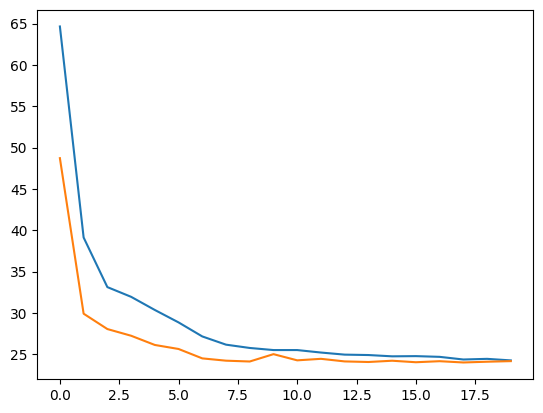

In [117]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

In [142]:
new_image = mpimg.imread('images (2).jpg')

In [143]:
new_image = cv2.resize(new_image, (150, 150))
new_image = cv2.cvtColor(new_image, cv2.COLOR_BGR2GRAY)
new_image = new_image.reshape(1, 150, 150, 1)
new_image = new_image / 255

In [144]:
xmin, ymin, xmax, ymax = model.predict(new_image)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


In [145]:
xmin = int(xmin)
ymin = int(ymin)
xmax = int(xmax)
ymax = int(ymax)

In [146]:
new_image = new_image.reshape(150, 150, 1)

In [147]:
new_image_copy = new_image.copy()

In [148]:
cv2.rectangle(new_image_copy, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)

array([[[0.6745098 ],
        [0.70196078],
        [0.71372549],
        ...,
        [0.44705882],
        [0.35686275],
        [0.39607843]],

       [[0.68235294],
        [0.70980392],
        [0.72156863],
        ...,
        [0.45882353],
        [0.36078431],
        [0.37254902]],

       [[0.66666667],
        [0.69019608],
        [0.70196078],
        ...,
        [0.4       ],
        [0.39607843],
        [0.4       ]],

       ...,

       [[0.45490196],
        [0.43137255],
        [0.44313725],
        ...,
        [0.26666667],
        [0.22745098],
        [0.22352941]],

       [[0.43137255],
        [0.41960784],
        [0.44705882],
        ...,
        [0.23137255],
        [0.25098039],
        [0.25882353]],

       [[0.42745098],
        [0.41960784],
        [0.42352941],
        ...,
        [0.24705882],
        [0.23529412],
        [0.25098039]]], shape=(150, 150, 1))

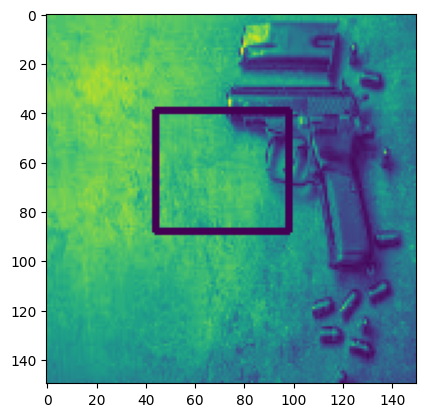

In [149]:
plt.imshow(new_image_copy)